![FMD_Overview](https://github.com/edkreuk/FMD_FRAMEWORK/blob/main/Images/FMD_DOMAIN_OVERVIEW.png?raw=true)

In [1]:
%pip install ms-fabric-cli pillow cairosvg --quiet

Note: you may need to restart the kernel to use updated packages.


# Configuration and Parameters

**Fabric Administrator Role is required to create domain**

In [2]:
assign_icons = True                                # Set to True to assign default icons to workspaces; set to False if you have already assigned custom icons
lakehouse_schema_enabled = True                     # Set to True if you want to use the lakehouse schema, otherwise set to False

driver = '{ODBC Driver 18 for SQL Server}'          # Change this if you use a different driver
overwrite_variable_library=True                    # By default the Library is overwritten, change this to "False" if you have custom changes
spark_version='2.0'

## KeyVault settings
For future usage

In [3]:
key_vault_uri_name='val_key_vault_uri_name'
purview_account_name='val_purview_account_name'

## Shortcut settings

In [4]:
##No need to fill in the first time, because the workspaces does not exist yet. After the first run, you can fill in the workspace and lakehouse ids to speed up the deployment process, otherwise the script will look them up by name every time which takes more time.
##Used for Shortcuts, can also manualy filled in
SourceWorkspaceId=''                            
SourceLakehouseId=''                            # Your Gold lakehouse  
SourceSchema=''
Shortcut_TargetSchema=''
Shortcut_TargetWorkspaceId=''
Shortcut_TargetLakehouseId=''                   # Your Silver Lakehouse

## Capacity configuration

In [5]:
reassign_capacity= True                                        # If set to False existing assigned capacities to workspaces will no be overwritten

capacity_name_business_domain_dvlm = '<your capacity name>'              # Which capacity will be used for the workspaces in this business domain
capacity_name_business_domain_prod = '<your capacity name>'              # Which capacity will be used for the workspaces in this business domain

## Domain and Framework settings

In [6]:
framework_post_fix= ''                                   # post fix to be added at the end of workspace for example INTEGRATION CODE(D) FMD
if framework_post_fix != '':
   framework_post_fix= ' '+ framework_post_fix           #If empty leave as is else add a space before for better visibility

##Domains
create_domains=  True                                    # If you do not have a Fabric Admin role, you need to set this option to False. For domain creation the Fabric Admin role is needed

business_domain_names= ['FINANCE','SALES']               # Define business domains
domain_contributor_role = {"type": "Contributors","principals": [{"id": "00000000-0000-0000-0000-000000000000","type": "Group"}  ]}  # Which group(Object ID) can add or remove workspaces to this domain
configuration_database_workspace='INTEGRATION CONFIG'    # Name of the workspace of Fabric database which was deployed for the Integration Domain
configuration_database_name='SQL_INTEGRATION_FRAMEWORK'  # Name of the Fabric database which was deployed for the Integration Domain

In [7]:
configuration = {
                    'workspace': {
                        'name' : configuration_database_workspace            # Name of target workspace
                                       },
                    'DatabaseName' : configuration_database_name                    # Name of target configuration SQL Database
}

# Configuration


## Repo Configuration

In [8]:
#FMD Framework code
##### DO NOT CHANGE UNLESS SPECIFIED OTHERWISE ####
repo_owner = "edkreuk"              # Owner of the repository
repo_name = "FMD_FRAMEWORK"         # Name of the repository
branch = "main" is default                    
folder_prefix = ""
###################################################

## Workspace Roles Configuration

In [9]:
workspace_roles_data_business_domain = [ # Keep emtpy [] if you only want to assign this to your personal account
                    {
                      "principal": {
                            "id": '00000000-0000-0000-0000-000000000000',
                             "type": "Group"
                        },
                        "role": "admin"  #(choose from 'admin', 'member', 'contributor', 'viewer')
                        }
                    ]

workspace_roles_code_business_domain = [ # Keep emtpy [] if you only want to assign this to your personal account
                    {
                      "principal": {
                            "id": '00000000-0000-0000-0000-000000000000',
                             "type": "Group"
                        },
                        "role": "admin"  #(choose from 'admin', 'member', 'contributor', 'viewer')
                        }
                    ]

workspace_roles_reporting_business_domain = [ # Keep emtpy [] if you only want to assign this to your personal account
                    {
                        "principal": {
                            "id": '00000000-0000-0000-0000-000000000000',
                            "type": "Group"
                        },
                        "role": "admin"  #(choose from 'admin', 'member', 'contributor', 'viewer')
                        }
                    ]

## Business Domain Configuration

In [10]:
##### DO NOT CHANGE UNLESS SPECIFIED OTHERWISE, FE ADDING NEW ENVIRONMENTS ####
business_domain_deployment = [
                    {
                        'environment_name' : 'development',                                 # Name of target environment
                        'environment_short' : 'D',                                          # Short of target environment
                        'workspaces': {
                         
                            'data' : {
                                'roles' : workspace_roles_data_business_domain,             # Roles to assign to the workspace
                                'capacity_name' : capacity_name_business_domain_dvlm        # Name of target data workspace for development
                            },
                            'code' : {
                                'roles' : workspace_roles_code_business_domain,             # Roles to assign to the workspace
                                'capacity_name' : capacity_name_business_domain_dvlm        # Name of target code workspace for development
                            },
                            'reporting' : {
                            'roles' : workspace_roles_reporting_business_domain,            # Roles to assign to the workspace
                            'capacity_name' : capacity_name_business_domain_dvlm            # Name of target code workspace for development
                            },
                            'semantic' : {
                            'roles' : workspace_roles_reporting_business_domain,            # Roles to assign to the workspace
                            'capacity_name' : capacity_name_business_domain_dvlm            # Name of target code workspace for development
                            }
                        }
                    },
                    {
                        'environment_name' : 'production',                                  # Name of target environment
                        'environment_short' : 'P',                                          # Short of target environment
                        'workspaces': {
                         
                            'data' : {
                                'roles' : workspace_roles_data_business_domain,             # Roles to assign to the workspace
                                'capacity_name' : capacity_name_business_domain_prod        # Name of target data workspace for development
                            },
                            'code' : {
                                'roles' : workspace_roles_code_business_domain,             # Roles to assign to the workspace
                                'capacity_name' : capacity_name_business_domain_prod        # Name of target code workspace for development
                            },
                            'reporting' : {
                                'roles' : workspace_roles_reporting_business_domain,        # Roles to assign to the workspace
                                'capacity_name' : capacity_name_business_domain_prod        # Name of target code workspace for development
                            },
                            'semantic' : {
                                'roles' : workspace_roles_reporting_business_domain,        # Roles to assign to the workspace
                                'capacity_name' : capacity_name_business_domain_prod        # Name of target code workspace for development
                            }
                        }
                    }
                ]
###################################################

## Download source & config files

In [11]:
import subprocess
import os
from time import sleep, time
import json
import shutil
import re
import requests
import zipfile
import yaml
import struct
import pyodbc
import cairosvg
import base64
import xml.etree.ElementTree as ET

from PIL import Image, ImageDraw, ImageFont
from requests.adapters import HTTPAdapter, Retry
from io import BytesIO
from zipfile import ZipFile 

In [12]:
def download_folders_as_zip(repo_owner, repo_name, output_zip, branch="main", folders_to_extract=None, remove_folder_prefix=""):
    if folders_to_extract is None:
        folders_to_extract = []

    # Construct the URL for the GitHub API to download the repository as a zip file
    url = f"https://api.github.com/repos/{repo_owner}/{repo_name}/zipball/{branch}"
    response = requests.get(url)
    response.raise_for_status()

    # Ensure the directory for the output zip file exists
    os.makedirs(os.path.dirname(output_zip), exist_ok=True)

    # Create a zip file in memory from GitHub response
    with zipfile.ZipFile(BytesIO(response.content)) as zipf:
        # Open output zip in append mode
        with zipfile.ZipFile(output_zip, 'w') as output_zipf:
            
            for file_info in zipf.infolist():
                for folder in folders_to_extract:
                    folder_path = f"/{folder}" if not folder.startswith("/") else folder
                    if re.sub(r'^.*?/', '/', file_info.filename).startswith(folder_path):
                        file_data = zipf.read(file_info.filename)
                        parts = file_info.filename.split('/')
                        if remove_folder_prefix:
                            parts = [p for p in parts if p != remove_folder_prefix]
                        output_zipf.writestr('/'.join(parts[1:]), file_data)

def uncompress_zip_to_folder(zip_path, extract_to):
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    os.remove(zip_path)

def copy_to_tmp(name):
    shutil.rmtree("./builtin/tmp", ignore_errors=True)
    path2zip = "./builtin/src/src.zip"

    prefixes = [
        f"src/{name}"
    ]

    with ZipFile(path2zip) as archive:
        for prefix in prefixes:
            matched_files = [file for file in archive.namelist() if file.startswith(prefix)]
            if matched_files:
                for file in matched_files:
                    archive.extract(file, "./builtin/tmp")
                return f"./builtin/tmp/{prefix}"  # Return only the first matching prefix

    return None  # Nothing found

# ✅ Combine all folders into one zip
download_folders_as_zip(repo_owner, repo_name, output_zip = "./builtin/src/src.zip", branch = branch, folders_to_extract= [f"{folder_prefix}/src"] , remove_folder_prefix = f"{folder_prefix}")
download_folders_as_zip(repo_owner, repo_name, output_zip = "./builtin/config/config.zip", branch = branch, folders_to_extract= [f"{folder_prefix}/config"] , remove_folder_prefix = f"{folder_prefix}")
# ✅ Uncompress everything into ./builtin
uncompress_zip_to_folder(zip_path = "./builtin/config/config.zip", extract_to= "./builtin")

mapping_table=[]
tasks=[]


# CLI Login

In [13]:
# Set environment parameters for Fabric CLI
token = notebookutils.credentials.getToken('pbi')
os.environ['FAB_TOKEN'] = token
os.environ['FAB_TOKEN_ONELAKE'] = token

# Deployment functions

## Load configuration


In [14]:
base_path = './builtin/'
config_path = os.path.join(base_path, 'config/item_config.yaml')

with open(config_path, 'r') as file:
        config = yaml.safe_load(file)

deploy_order_path = os.path.join(base_path, 'config/item_initial_setup.json')
with open(deploy_order_path, 'r') as file:
        item_initial_setup =json.load(file)

deploy_order_path = os.path.join(base_path, 'config/data_deployment.json')
with open(deploy_order_path, 'r') as file:
        data_deployment =json.load(file)

deploy_order_path = os.path.join(base_path, 'config/item_deployment_code_business_domain.json')
with open(deploy_order_path, 'r') as file:
        item_deployment_code_business_domain =json.load(file)

deploy_order_path = os.path.join(base_path, 'config/item_deployment_data_business_domain.json')
with open(deploy_order_path, 'r') as file:
        item_deployment_data_business_domain =json.load(file)

deploy_icons_path = os.path.join(base_path, 'config/fabric_icons.xml')

# Parse the XML file
tree = ET.parse(deploy_icons_path)
root = tree.getroot()

# Create a dictionary to store icon name and base64
fabric_icons_fmd = {}
for item in root.findall('icon'):
    name = item.find('name').text if item.find('name') is not None else "No name"
    base64_str = item.find('base64').text if item.find('base64') is not None else ""
    fabric_icons_fmd[name] = base64_str


# Deployment

## Load latest version NB_UTILITIES_SETUP_FMD

In [15]:
def run_fab_command(command, capture_output=False, silently_continue=False, raw_output=False):
    """
    Executes a Fabric CLI command with optional output capture and error handling.
    """
    result = subprocess.run(["fab", "-c", command], capture_output=capture_output, text=True)
    if not silently_continue and (result.returncode > 0 or result.stderr):
        raise Exception(f"Error running fab command. exit_code: '{result.returncode}'; stderr: '{result}'")
    if capture_output:
        return result if raw_output else result.stdout.strip()
    return None

In [16]:
workspace_id = notebookutils.runtime.context.get('currentWorkspaceId')
result=run_fab_command("api -X get workspaces/"+workspace_id, capture_output=True, silently_continue=False)
workspace_name=json.loads(result)["text"]["displayName"]

for it in item_initial_setup:
    name = it["name"]
    type = it["type"]
    tmp_path = copy_to_tmp(name)

    cli_parameter = ''

    if "Notebook" in name:
        cli_parameter += " --format .py"
        result = run_fab_command(f"import {workspace_name}.Workspace/{name} -i {tmp_path} -f {cli_parameter}",capture_output=False, silently_continue=True)



* 'NB_UTILITIES_SETUP_FMD.Notebook' imported



In [17]:
%run NB_UTILITIES_SETUP_FMD

In [18]:
variable_parameters.update ( {
     "SourceWorkspaceId": SourceWorkspaceId,
      "SourceLakehouseId": SourceLakehouseId,
       "SourceSchema": SourceSchema,
        "Shortcut_TargetSchema": Shortcut_TargetSchema,
         "Shortcut_TargetWorkspaceId": Shortcut_TargetWorkspaceId,
          "Shortcut_TargetLakehouseId": Shortcut_TargetLakehouseId,
})

## Integration Domain

### Get Fabric database (Configuration)

In [19]:
for deployment_item in data_deployment:
        if deployment_item['type'] in ('SQLDatabase'):
                name = configuration['DatabaseName']
                type = deployment_item["type"]
                name=name+'.'+type
                server, database_name=deploy_item(workspace_name=configuration['workspace']['name'],name=name,mapping_table=mapping_table, environment_name='config',tasks= tasks, lakehouse_schema_enabled=lakehouse_schema_enabled,it=deployment_item)

##!NOTE: in Case of an error check if you're not using a trial capacitiy or the capacity you assigned is paused


* Item updated

✅ Description applied to SQL_INTEGRATION_FRAMEWORK.SQLDatabase in 'INTEGRATION CONFIG'
✅ SQL_INTEGRATION_FRAMEWORK.SQLDatabase Created/Imported'
✅ Folder Database assigned to item in 'INTEGRATION CONFIG'


## Business Domain

### Create workspaces(Business Domains)

In [20]:
for business_domain_name in business_domain_names:
    if create_domains:
        create_fabric_domain(business_domain_name)

    for business_domain in business_domain_deployment:
        print(f"--------------------------")
        print(f"Updating Workspace: {business_domain['environment_name']}")
        deploy_workspaces(business_domain_name,workspace=business_domain['workspaces']['code'],workspace_name=business_domain_name + ' CODE ('+business_domain['environment_short']+')'+framework_post_fix,  environment_name=business_domain['environment_name'], old_id=config["workspaces"]["workspace_business_domain_code"], mapping_table=mapping_table, tasks=tasks)
        deploy_workspaces(business_domain_name,workspace=business_domain['workspaces']['data'],workspace_name=business_domain_name + ' DATA ('+business_domain['environment_short']+')'+framework_post_fix,  environment_name=business_domain['environment_name'], old_id=config["workspaces"]["workspace_business_domain_data"], mapping_table=mapping_table, tasks=tasks)
        deploy_workspaces(business_domain_name,workspace=business_domain['workspaces']['reporting'],workspace_name=business_domain_name + ' REPORTING ('+business_domain['environment_short']+')'+framework_post_fix, environment_name=business_domain['environment_name'], old_id=config["workspaces"]["workspace_business_domain_reporting"], mapping_table=mapping_table, tasks=tasks)
        deploy_workspaces(business_domain_name,workspace=business_domain['workspaces']['semantic'],workspace_name=business_domain_name + ' SEMANTIC ('+business_domain['environment_short']+')'+framework_post_fix, environment_name=business_domain['environment_name'], old_id=config["workspaces"]["workspace_business_domain_reporting"], mapping_table=mapping_table, tasks=tasks)


* Domain updated

✅ Description applied to FINANCE 
✅ Contributor role applied to FINANCE
--------------------------
Updating Workspace: development

#############################################
 - Processing: workspace FINANCE CODE (D)
 - Workspace 'FINANCE CODE (D)' found. Workspace ID: e5b5f64c-8af4-4b04-8c32-4c00d70a5170
 - Assigning capacity: Trial-Erwin

* Workspace updated

✅ Description applied to 'FINANCE CODE (D)'
 - Assigning Workspace roles
✅'{'id': '86897900-8de5-4894-ae41-1b4d1642acda', 'type': 'Group'}' assigned to admin role in 'FINANCE CODE (D)'
✅ Managed identity created in 'FINANCE CODE (D)'
✅ Managed identity assigned to contributor role in 'FINANCE CODE (D)'
✅ Spark version 2.0 has applied to FINANCE CODE (D)
✅ FINANCE domain assigned to 'FINANCE CODE (D)'

#############################################
 - Processing: workspace FINANCE DATA (D)
 - Workspace 'FINANCE DATA (D)' found. Workspace ID: e56f3ab0-8f18-4e27-a648-2bc8c24f21b1
 - Assigning capacity: Trial-Er

! Modifying properties may lead to unintended consequences
Setting new property for 'FINANCE REPORTING (P).Workspace'...
! Modifying properties may lead to unintended consequences
Setting new property for 'SALES SEMANTIC (D).Workspace'...
! Modifying properties may lead to unintended consequences
Setting new property for 'SALES REPORTING (P).Workspace'...


### Create Lakehouses(Business Domains)

In [21]:
for workspace_business_domain in business_domain_deployment:
    for business_domain in business_domain_names:
        for workspace in [workspace_business_domain['workspaces']['data']]:
            exclude = []
            for it in item_deployment_data_business_domain:
                new_id = None                    
                name = it["name"]
                type = it["type"]
                if name in exclude:
                    continue
                deploy_item(business_domain + ' DATA ('+ workspace_business_domain['environment_short']+')'+framework_post_fix, name,mapping_table, workspace_business_domain['environment_name'], tasks, lakehouse_schema_enabled,it)


#############################################
Deploying in FINANCE DATA (D): LH_GOLD_LAYER.Lakehouse
✅ Folder Lakehouses assigned to item in 'FINANCE DATA (D)'
Lakehouse already exists, skip creation

#############################################
Deploying in SALES DATA (D): LH_GOLD_LAYER.Lakehouse
✅ Folder Lakehouses assigned to item in 'SALES DATA (D)'
Lakehouse already exists, skip creation

#############################################
Deploying in FINANCE DATA (P): LH_GOLD_LAYER.Lakehouse
✅ Folder Lakehouses assigned to item in 'FINANCE DATA (P)'
Lakehouse already exists, skip creation

#############################################
Deploying in SALES DATA (P): LH_GOLD_LAYER.Lakehouse
✅ Folder Lakehouses assigned to item in 'SALES DATA (P)'
Lakehouse already exists, skip creation


### Create Items(Business Domains)

In [22]:
for workspace_business_domain in business_domain_deployment:
    for business_domain_name in business_domain_names:
        for workspace in [workspace_business_domain['workspaces']['code']]:
                for it in item_deployment_code_business_domain:
                    new_id = None
                    if it['type'] in ('VariableLibrary'):
                        name = it["name"]
                        type = it["type"]
                        deploy_item(business_domain_name + ' CODE ('+ workspace_business_domain['environment_short']+')'+framework_post_fix, name,mapping_table, workspace_business_domain['environment_name'], tasks, lakehouse_schema_enabled,it)


#############################################
Deploying in FINANCE CODE (D): VAR_GOLD_CODE_FMD.VariableLibrary
Creating or updating VariableLibrary: VAR_GOLD_CODE_FMD.VariableLibrary
✅ VAR_GOLD_CODE_FMD.VariableLibrary Created/Imported'
✅ Folder VariableLibraries assigned to item in 'FINANCE CODE (D)'
* 'VAR_GOLD_CODE_FMD.VariableLibrary' imported

#############################################
Deploying in FINANCE CODE (D): VAR_GOLD_SHORTCUTS_FMD.VariableLibrary
Creating or updating VariableLibrary: VAR_GOLD_SHORTCUTS_FMD.VariableLibrary
✅ VAR_GOLD_SHORTCUTS_FMD.VariableLibrary Created/Imported'
✅ Folder VariableLibraries assigned to item in 'FINANCE CODE (D)'
* 'VAR_GOLD_SHORTCUTS_FMD.VariableLibrary' imported

#############################################
Deploying in SALES CODE (D): VAR_GOLD_CODE_FMD.VariableLibrary
Creating or updating VariableLibrary: VAR_GOLD_CODE_FMD.VariableLibrary
✅ VAR_GOLD_CODE_FMD.VariableLibrary Created/Imported'
✅ Folder VariableLibraries assigned to ite

In [23]:
for workspace_business_domain in business_domain_deployment:
    for business_domain_name in business_domain_names:
        for workspace in [workspace_business_domain['workspaces']['code']]:
                for it in item_deployment_code_business_domain:
                    new_id = None
                    if it['type'] not in ('VariableLibrary'):
                        name = it["name"]
                        type = it["type"]
                        deploy_item(business_domain_name + ' CODE ('+ workspace_business_domain['environment_short']+')'+framework_post_fix, name,mapping_table, workspace_business_domain['environment_name'], tasks, lakehouse_schema_enabled,it)


#############################################
Deploying in FINANCE CODE (D): NB_LOAD_GOLD.Notebook

* Item updated

✅ Description applied to NB_LOAD_GOLD.Notebook in 'FINANCE CODE (D)'
✅ Folder Notebooks assigned to item in 'FINANCE CODE (D)'
* 'NB_LOAD_GOLD.Notebook' imported

#############################################
Deploying in FINANCE CODE (D): NB_MLV_EXAMPLE.Notebook

* Item updated

✅ Description applied to NB_MLV_EXAMPLE.Notebook in 'FINANCE CODE (D)'
✅ Folder Notebooks assigned to item in 'FINANCE CODE (D)'
* 'NB_MLV_EXAMPLE.Notebook' imported

#############################################
Deploying in FINANCE CODE (D): NB_MLV_DEMO_GOLD.Notebook

* Item updated

✅ Description applied to NB_MLV_DEMO_GOLD.Notebook in 'FINANCE CODE (D)'
✅ Folder Notebooks assigned to item in 'FINANCE CODE (D)'
* 'NB_MLV_DEMO_GOLD.Notebook' imported

#############################################
Deploying in FINANCE CODE (D): NB_CREATE_DIMDATE.Notebook

* Item updated

✅ Description applied t

! Modifying properties may lead to unintended consequences
Setting new property for 'NB_MLV_EXAMPLE.Notebook'...
! Modifying properties may lead to unintended consequences
Setting new property for 'NB_MLV_DEMO_GOLD.Notebook'...
! Modifying properties may lead to unintended consequences
Setting new property for 'NB_CREATE_SHORTCUTS.Notebook'...
! Modifying properties may lead to unintended consequences
Setting new property for 'NB_MLV_EXAMPLE.Notebook'...


## Workspace Icons

In [24]:
if assign_icons:  
    seen = set()
    workspaces = []
    # Get cluster URL for use in metadata endpoints
    cluster_base_url = get_cluster_url()

    for item in mapping_table:
        if item['ItemType'] == 'Workspace':
            key = (item['Description'], item['new_id'])
            if key not in seen:
                seen.add(key)
                workspaces.append({'displayName': item['Description'], 'id': item['new_id']})
    fabric_icons = fabric_icons_fmd 

    for workspace in workspaces:
        display_name = workspace['displayName'].lower()
       
        # Assign icon
        for icon_key, icon_value in workspace_icon_def['icons'].items():
            if icon_key in display_name:
                workspace["icon"] = icon_value
                workspace_icon = fabric_icons.get(icon_value)
                break
        else:
            workspace["icon"] = None
            workspace_icon = None

        workspace["icon_base64img"] = workspace_icon

e5b5f64c-8af4-4b04-8c32-4c00d70a5170,,
e56f3ab0-8f18-4e27-a648-2bc8c24f21b1,,
5de7cfed-3057-480a-a5b5-94fee82149d6,,
9573d3f7-5651-4ac5-96b5-0819cedfa663,,
6c215ac5-47e4-4535-969f-9afc5fabc3c1,,
6dfd194f-c22a-4989-b7a1-7afd680c19cb,,
6664fd6d-cdb8-4239-9710-57f0e4918674,,
ae482685-6532-45ad-a7a1-fd184150ed4c,,
a188923f-c996-4283-af26-881563febb3c,,
89c45add-7ca9-4fdf-be0f-8e5665294031,,
f2875cf1-58e5-4f23-a3c0-d2202c33de6a,,

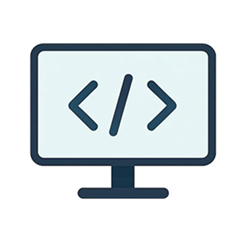
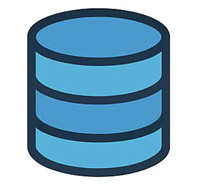
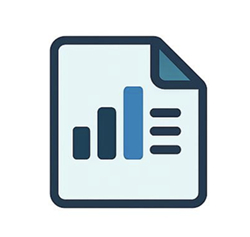
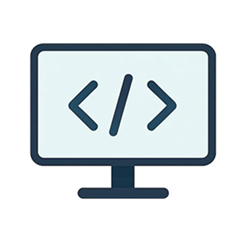
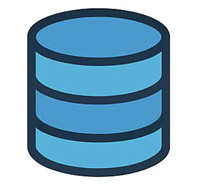
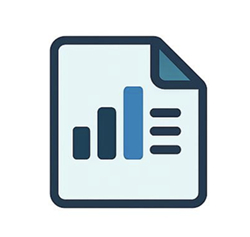
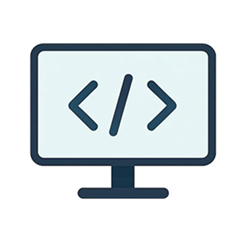
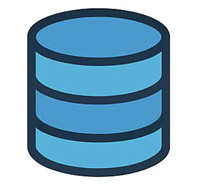
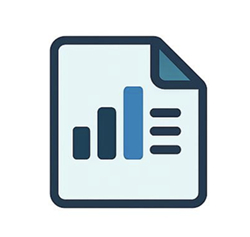
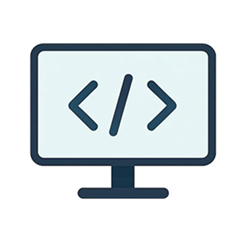
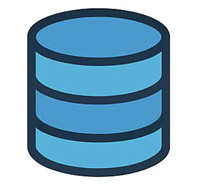
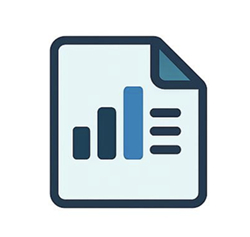

In [25]:
if assign_icons:
    # Dry run - Display pre and post icons based on specified workspace filters and workspace icon definition. Will NOT update any icons!
    display_workspace_icons(workspaces)
    sleep(2)

### Deploy Workspace Icons

In [26]:
if assign_icons:
    for workspace in workspaces:
            set_workspace_icon(workspace.get('id'), workspace.get('icon_base64img'))

## Create SQL deployment Manifest

### Add Workspaces to Fabric Database

In [27]:
#add all created workspace to database
custom_sql_deployment = {"queries_stored_procedures": []}
unique_items = {}
for item in mapping_table:
    if item.get("ItemType") == "Workspace":
        unique_items[item["new_id"]] = item["Description"]

# Convert to list of tuples or dicts
workspaces = [{"Description": desc, "new_id": nid} for nid, desc in unique_items.items()]

for workspace in workspaces:
    print(f'EXEC [integration].[sp_UpsertWorkspace](@WorkspaceId = "{workspace["new_id"]}" ,@Name = "{workspace["Description"]}")')
    custom_sql_deployment["queries_stored_procedures"].append(f'EXEC [integration].[sp_UpsertWorkspace] @WorkspaceId = "{workspace["new_id"]}", @Name = "{workspace["Description"]}"')

EXEC [integration].[sp_UpsertWorkspace](@WorkspaceId = "e5b5f64c-8af4-4b04-8c32-4c00d70a5170" ,@Name = "FINANCE CODE (D)")
EXEC [integration].[sp_UpsertWorkspace](@WorkspaceId = "e56f3ab0-8f18-4e27-a648-2bc8c24f21b1" ,@Name = "FINANCE DATA (D)")
EXEC [integration].[sp_UpsertWorkspace](@WorkspaceId = "5de7cfed-3057-480a-a5b5-94fee82149d6" ,@Name = "FINANCE REPORTING (D)")
EXEC [integration].[sp_UpsertWorkspace](@WorkspaceId = "9573d3f7-5651-4ac5-96b5-0819cedfa663" ,@Name = "FINANCE SEMANTIC (D)")
EXEC [integration].[sp_UpsertWorkspace](@WorkspaceId = "6c215ac5-47e4-4535-969f-9afc5fabc3c1" ,@Name = "FINANCE CODE (P)")
EXEC [integration].[sp_UpsertWorkspace](@WorkspaceId = "6dfd194f-c22a-4989-b7a1-7afd680c19cb" ,@Name = "FINANCE DATA (P)")
EXEC [integration].[sp_UpsertWorkspace](@WorkspaceId = "6664fd6d-cdb8-4239-9710-57f0e4918674" ,@Name = "FINANCE REPORTING (P)")
EXEC [integration].[sp_UpsertWorkspace](@WorkspaceId = "ae482685-6532-45ad-a7a1-fd184150ed4c" ,@Name = "FINANCE SEMANTIC (P)"

In [28]:
for workspace_business_domain in business_domain_deployment:
    for business_domain_name in business_domain_names:
        for workspace in [workspace_business_domain['workspaces']['code']]:
                workspace_id = get_workspace_id_by_name(business_domain_name + ' CODE ('+ workspace_business_domain['environment_short']+')'+framework_post_fix)
                result = run_fab_command(f"api -X get workspaces/{workspace_id}/items", capture_output=True, silently_continue=True)
                existing_items = json.loads(result)['text']
                for item in existing_items.get('value', []):
                    if item['type'] == 'DataPipeline':
                        print(f'EXEC [integration].[sp_UpsertPipeline] @PipelineId = "{item["id"]}", @WorkspaceId = "{workspace_id}" ,@Name = "{item["displayName"]}"')
                        custom_sql_deployment["queries_stored_procedures"].append(f'EXEC [integration].[sp_UpsertPipeline] @PipelineId = "{item["id"]}", @WorkspaceId = "{workspace_id}" ,@Name = "{item["displayName"]}"')

EXEC [integration].[sp_UpsertPipeline] @PipelineId = "2592e04d-b893-423e-8a01-4a7071611fcf", @WorkspaceId = "a188923f-c996-4283-af26-881563febb3c" ,@Name = "PL_TEST"
EXEC [integration].[sp_UpsertPipeline] @PipelineId = "069b77c9-21a1-441a-95ec-a2a491af2861", @WorkspaceId = "a188923f-c996-4283-af26-881563febb3c" ,@Name = "Pipeline_1"


### Add Lakehouses to Fabric Database

In [29]:
for workspace_business_domain in business_domain_deployment:
    for business_domain_name in business_domain_names:
        for workspace in [workspace_business_domain['workspaces']['data']]:
                workspace_id = get_workspace_id_by_name(business_domain_name + ' DATA ('+ workspace_business_domain['environment_short']+')'+framework_post_fix)
                result = run_fab_command(f"api -X get workspaces/{workspace_id}/items", capture_output=True, silently_continue=True)
                existing_items = json.loads(result)['text']
                for item in existing_items.get('value', []):
                    if item['type'] == 'Lakehouse':
                        print(f'EXEC [integration].[sp_UpsertLakehouse] @LakehouseId = "{item["id"]}", @WorkspaceId = "{workspace_id}" ,@Name = "{item["displayName"]}"')
                        custom_sql_deployment["queries_stored_procedures"].append(f'EXEC [integration].[sp_UpsertLakehouse] @LakehouseId = "{item["id"]}", @WorkspaceId = "{workspace_id}" ,@Name = "{item["displayName"]}"')
                        

EXEC [integration].[sp_UpsertLakehouse] @LakehouseId = "a6c3cf9b-40c8-4663-a3d3-528ac3649b54", @WorkspaceId = "e56f3ab0-8f18-4e27-a648-2bc8c24f21b1" ,@Name = "LH_GOLD_LAYER"
EXEC [integration].[sp_UpsertLakehouse] @LakehouseId = "63ddad67-a2c0-424b-bae6-d93db2fc592a", @WorkspaceId = "89c45add-7ca9-4fdf-be0f-8e5665294031" ,@Name = "LH_GOLD_LAYER"
EXEC [integration].[sp_UpsertLakehouse] @LakehouseId = "4964058a-f01f-4398-9426-4d86dc40682b", @WorkspaceId = "89c45add-7ca9-4fdf-be0f-8e5665294031" ,@Name = "LH_SILVER_LAYER"
EXEC [integration].[sp_UpsertLakehouse] @LakehouseId = "236dd93b-f061-43b3-814b-c9e55767559e", @WorkspaceId = "6dfd194f-c22a-4989-b7a1-7afd680c19cb" ,@Name = "LH_GOLD_LAYER"
EXEC [integration].[sp_UpsertLakehouse] @LakehouseId = "7e23ead0-6de0-4502-afe2-ef85731f7686", @WorkspaceId = "2879e25a-94d5-4cd9-b613-1688c20a32b0" ,@Name = "LH_GOLD_LAYER"


## Deploy SQL Code

In [30]:
#Make sure out token is still valid before we continou, sometime it can take a bit longer that's we will check it again
token = notebookutils.credentials.getToken('pbi')
os.environ['FAB_TOKEN'] = token
os.environ['FAB_TOKEN_ONELAKE'] = token

In [31]:
for deployment_item in data_deployment:
        if deployment_item['type'] in ('SQLDatabase'):
                name = configuration['DatabaseName']
                type = deployment_item["type"]
                name=name+'.'+type
                if not server:         #it was already set, just in case
                    server=get_item_id(configuration['workspace']['name'], name, 'properties.serverFqdn')
                if not database_name:    
                    database_name=get_item_id(configuration['workspace']['name'], name, 'properties.databaseName')

try:
    i = 0

    token = notebookutils.credentials.getToken('pbi').encode('utf-16-le')
    token_struct = struct.pack(f'<I{len(token)}s', len(token), token)

    print(f"DRIVER={driver};SERVER={server};PORT=1433;DATABASE={database_name};")
    connection = pyodbc.connect(f"DRIVER={driver};SERVER={server};DATABASE={database_name};", attrs_before={1256:token_struct}, timeout=12)

    with connection.cursor() as cursor:
        cursor.execute("SELECT 1")  # Execute the warm-up query (a simple query like 'SELECT 1' can be used)
        cursor.fetchone()
        connection.timeout = 10  # Setting a lower timeout for subsequent queries

    for i, query in enumerate(custom_sql_deployment["queries_stored_procedures"]):
        print(f' - execute "{query}"')
        cursor.execute(query)
        cursor.commit()


    tasks.append({"task_name":f"{workspace.get('displayName')} {database_name} query {i}", "task_duration": 1, "status": f"success"})
except pyodbc.OperationalError as e:
    print(e) 
    tasks.append({"task_name":f"{workspace.get('displayName')} {database_name} query {i}", "task_duration": 1, "status": f"pyodbc failed: {e}"})
except Exception as e:
    print(e) 
    tasks.append({"task_name":f"{workspace.get('displayName')} {database_name} query {i}", "task_duration": 1, "status": f"failed: {e}"})

DRIVER={ODBC Driver 18 for SQL Server};SERVER=nl7yhqnbrscude3yv6mas6bxpq-gh2fbc4gei3epemc77id636zk4.database.fabric.microsoft.com,1433;PORT=1433;DATABASE=SQL_INTEGRATION_FRAMEWORK-f55881f4-6747-4df9-9b21-6231fdc64395;
 - execute "EXEC [integration].[sp_UpsertWorkspace] @WorkspaceId = "e5b5f64c-8af4-4b04-8c32-4c00d70a5170", @Name = "FINANCE CODE (D)""
 - execute "EXEC [integration].[sp_UpsertWorkspace] @WorkspaceId = "e56f3ab0-8f18-4e27-a648-2bc8c24f21b1", @Name = "FINANCE DATA (D)""
 - execute "EXEC [integration].[sp_UpsertWorkspace] @WorkspaceId = "5de7cfed-3057-480a-a5b5-94fee82149d6", @Name = "FINANCE REPORTING (D)""
 - execute "EXEC [integration].[sp_UpsertWorkspace] @WorkspaceId = "9573d3f7-5651-4ac5-96b5-0819cedfa663", @Name = "FINANCE SEMANTIC (D)""
 - execute "EXEC [integration].[sp_UpsertWorkspace] @WorkspaceId = "6c215ac5-47e4-4535-969f-9afc5fabc3c1", @Name = "FINANCE CODE (P)""
 - execute "EXEC [integration].[sp_UpsertWorkspace] @WorkspaceId = "6dfd194f-c22a-4989-b7a1-7afd68

In [32]:
display(tasks)